In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from dotenv import load_dotenv

In [6]:
load_dotenv()

True

In [7]:
TRAIN_DIR = os.getenv("train_folder")
TEST_DIR = os.getenv("test_folder")
VALID_DIR = os.getenv("valid_folder")

In [8]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

In [9]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

In [10]:
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.15),
    transforms.ToTensor()
])

In [11]:
valid_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

In [12]:
train_dataset = ImageFolder(root = TRAIN_DIR, transform = train_transforms)
valid_dataset = ImageFolder(root = VALID_DIR, transform= valid_transforms)

In [13]:
class_names = train_dataset.classes
print(len(class_names))
class_names

38


['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [14]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [15]:
images, labels = next(iter(train_dataloader))

C:\Users\rudeu\AppData\Local\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [16]:
images[0].shape

torch.Size([3, 224, 224])

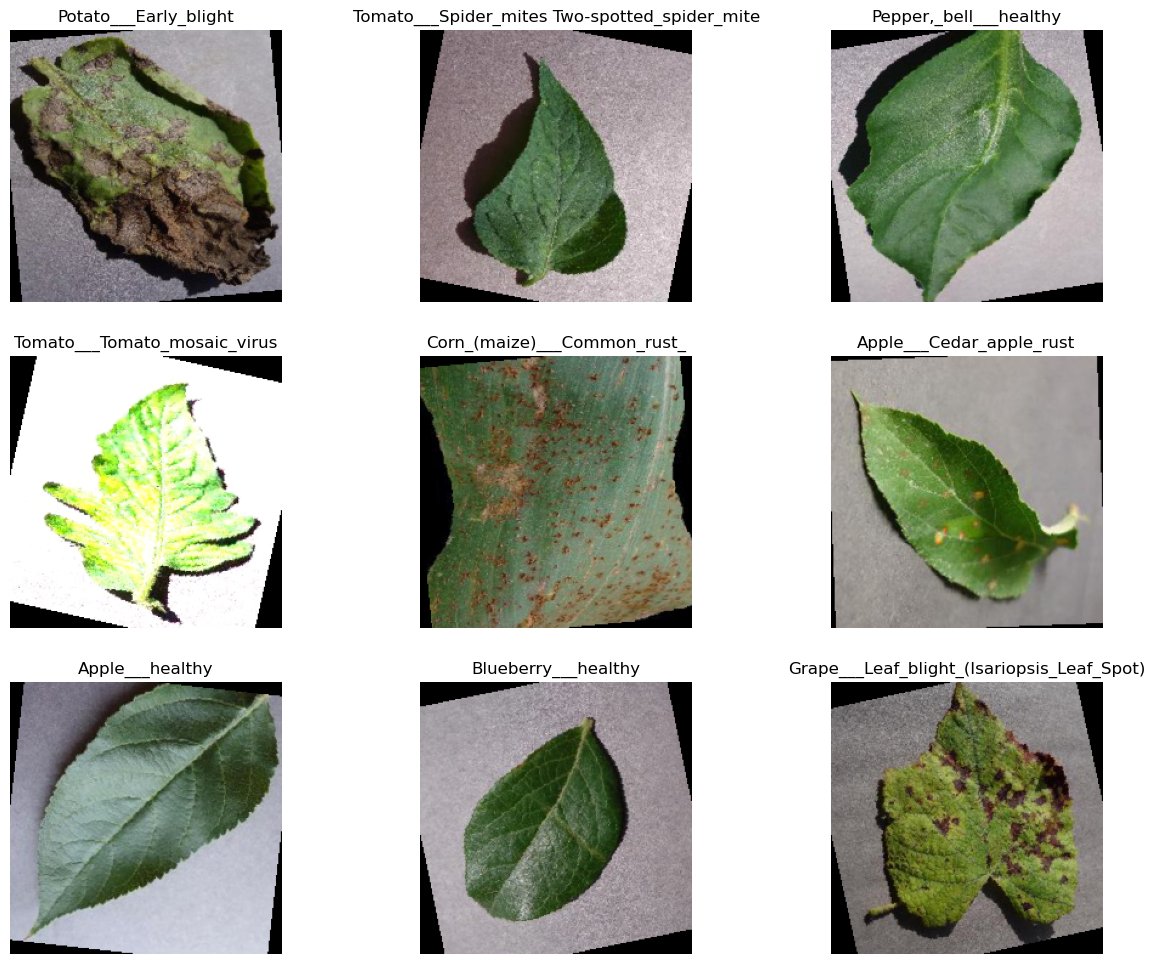

In [17]:
plt.figure(figsize=(15, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    img = images[i].permute(1, 2, 0)

    plt.imshow(img)

    plt.title(class_names[labels[i]], fontsize=12)

    plt.axis("off")


plt.show()

In [18]:
3*224*224

16*224*224
16*112*112

32*112*112
32*56*56

64*56*56
64*28*28

50176

In [19]:
class CustomNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.feature_extract = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3 , padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),


            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Dropout(0.2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64*28*28, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64,num_classes)
        )

    def forward(self,X):
        out = self.feature_extract(X)
        out = self.classifier(out)

        return out

In [20]:
learning_rate = 0.05
epochs = 10

In [21]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [22]:
model = CustomNN(num_classes=len(class_names)).to(device)

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [20]:
images, labels = next(iter(train_dataloader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 38])


In [ ]:
# Train time
train_losses = []
train_accs = []

model.train()

for epoch in range(epochs):
  total_batch_loss = 0.0

  correctly_predicted = 0
  total = 0

  for images, labels in train_dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    total_batch_loss += loss.item()
    total += len(labels)
    _,predicted = torch.max(output, 1)
    correctly_predicted += (predicted == labels).sum().item()
  
  epoch_loss = total_batch_loss/len(train_dataloader)
  acc = correctly_predicted/total
  
  train_losses.append(epoch_loss)
  train_accs.append(acc)

  print(f'epoch {epoch+1} accuracy: {acc} loss {epoch_loss}')


In [24]:
model.load_state_dict(torch.load('plant_cnn.pth', map_location=device))

<All keys matched successfully>

In [26]:
model

CustomNN(
  (feature_extract): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): ReLU()
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_feat